# Low-complexity qPCA algorithm

In this notebook, we implement the low-complexity quantum Principal Component Analysis (qPCA) algorithm proposed in:

[C. He, J. Li, W. Liu, and Z. J. Wang, A Low-Complexity Quantum Principal Component Analysis Algorithm", IEEE Transactions on Quantum Engineering, vol. 3, 1–13, 2022](https://ieeexplore.ieee.org/document/9669030)

The original qPCA introduced in [[5]](#ref5) extracts all eigenvalue/eigenvector pairs of a matrix into a quantum state, which is not optimal if one only wants the top components. [[4]](#ref4) fixed that issue with a [quantum singular value thresholding](https://arxiv.org/pdf/1806.01838) circuit that keeps only the components above a given threshold $\tau>0$, but at the cost of a heavier circuit (5 phase estimations and rotation-controlled gates, two places where approximation error creeps in). He et al.'s contribution consists in simplifying that thresholding circuit. Instead of encoding the filter as a rotation-controlled operation (which must numerically approximate an amplitude), they encode it as a CNOT gate triggered by a threshold test on the phase [register](https://en.wikipedia.org/wiki/Quantum_register). This cuts the circuit down to 3 phase estimations and roughly 3/5 of the gate count, while only introducing approximation error in one place (the reciprocal needed to compute $\tau/\lambda_k$ below) instead of two.

Classical PCA algorithm for a $N\times N$ symmetric matrix has a computational cost $O(N^3)$ (see [[2]](#ref2)). Like [[4]](#ref4)'s algorithm, He et al.'s method runs in time $O(t\,\mathrm{poly}(\log N))$ to extract the $t$ principal components (an exponential improvement over the cost of classical PCA) while using only $O(\log(N\kappa))$ qubits, where $\kappa$ is the [condition number](https://en.wikipedia.org/wiki/Condition_number#Matrices) of the matrix.

The algorithm of He et al. is segmented as follows (see Figures 2-3 of He et al. for details and notations):

> **Algorithm:** Low-Complexity qPCA Algorithm

> **Input:** A quantum state $|\psi_A\rangle=\tfrac1{\sqrt{N_1}}\sum_{k=1}^r\sigma_k|u_k\rangle|v_k\rangle$,
a unitary matrix $U_{PE} = e^{2\pi i t_0\rho_A}$ and a threshold constant $\tau>0$

> **Output:** A quantum state $|\psi_A'\rangle= \tfrac1{\sqrt{N_2}}\sum_{k=1}^T\sigma_k|\lambda_k\rangle|u_k\rangle|v_k\rangle$

> **Procedure:**

> **Step 1.** Prepare quantum state $|\psi_1\rangle=|0\rangle^{\rm Anc}|0\rangle^{\rm C}|0\rangle^{\rm A}|\psi_{A_0}\rangle^{\rm M}$

> **Step 2.** Perform the phase estimation $U_{PE}$ to obtain
$|\psi_2\rangle=\tfrac1{\sqrt{N_1}}|0\rangle^{\rm Anc}|0\rangle^{\rm C}\sum_{k=1}^r\sigma_k|\lambda_k\rangle^{\rm A}|u_k\rangle|v_k\rangle$

> **Step 3.** Perform the unitary operation $U_{\lambda,\tau}$ to obtain
$|\psi_3\rangle=\tfrac1{\sqrt{N_1}}\left(|0\rangle^{\rm Anc}\sum_{k=1}^t\sigma_k|y_k\rangle^{\rm C}|\lambda_k\rangle^{\rm A}|u_k\rangle|v_k\rangle
+|0\rangle^{\rm Anc}\sum_{k=t+1}^r\sigma_k|0\rangle^{\rm C}|\lambda_k\rangle^{\rm A}|u_k\rangle|v_k\rangle\right)$.

> **Step 4.** Perform the CNOT operation $CU$ to obtain
$|\psi_4\rangle=\tfrac1{\sqrt{N_1}}\left(\sum_{k=1}^t\sigma_k|1\rangle^{\rm Anc}|y_k\rangle^{\rm C}|\lambda_k\rangle^{\rm A}|u_k\rangle|v_k\rangle
+\sum_{k=t+1}^r\sigma_k|0\rangle^{\rm Anc}|0\rangle^{\rm C}|\lambda_k\rangle^{\rm A}|u_k\rangle|v_k\rangle\right)$

> **Step 5.** Perform the unitary operation $U^\dagger$ to obtain
$|\psi_5\rangle=\tfrac1{\sqrt{N_1}}\left(\sum_{k=1}^t\sigma_k|1\rangle^{\rm Anc}|u_k\rangle|v_k\rangle
+\sum_{k=t+1}^r\sigma_k|0\rangle^{\rm Anc}|u_k\rangle|v_k\rangle\right)$

> **Step 6.** Measurement. When the measurement of the top qubit is $1$, the remaining registers will collapse to
$|\psi_A'\rangle=\tfrac1{\sqrt{N_2}}\sum_{k=1}^t\sigma_k|u_k\rangle|v_k\rangle$

> **Step 7.** Extract top-$t$ largest eigenvalues from a phase estimation and get
$|\psi_A'\rangle=\tfrac1{\sqrt{N_2}}\sum_{k=1}^t\sigma_k|\lambda_k\rangle|u_k\rangle|v_k\rangle$

**Implementation in this notebook.** He et al.'s step 3 builds $y_k=(1-\tau/\lambda_k)_+$ using a Newton-iteration reciprocal subcircuit implemented with [Quantum Fourier Tranform](https://en.wikipedia.org/wiki/Quantum_Fourier_transform) (QFT) arithmetic, so that it works for arbitrary, not-known-in-advance eigenvalues on real hardware. Since PCA eigenvalues are non-negative, $y_k>0\Leftrightarrow\lambda_k>\tau$, so the logical effect of that subcircuit is a threshold comparison on the phase register. In this notebook we implement steps 3+4 directly as a quantum comparator (a handful of multi-controlled-X gates comparing the phase register against the constant $\tau$) rather than reconstructing the full Newton-iteration subcircuit gate-by-gate. This is logically equivalent to the operation He et al.'s circuit performs, and it keeps the notebook readable. The "low complexity" idea (CNOT gate instead of control-rotation, single place of approximation) is what's being demonstrated, not a full transpilation of every elementary QFT-adder gate from Figure 3 of He et al.

In [133]:
import math
import numpy as np
from scipy.linalg import expm
from collections import Counter
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile

# Fix how arrays are displayed when printed, does not change the underlying data

np.set_printoptions(precision=3, suppress=True)

# After installing pylatexenc, one must restart the notebook kernel

# First example: 2x2 matrix

Let $A_0$ be the $2\times2$ matrix of Section V.A of He et al.,
$$
A_0=\tfrac12
\begin{pmatrix}
3 & 1\\
1 & 3
\end{pmatrix}.
$$
Since $A_0\ge0$, its [singular value decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition) $A_0=U\Sigma V^T$ and [eigendecomposition](https://en.wikipedia.org/wiki/Eigendecomposition_of_a_matrix) $A_0=U\Lambda U^T$ coincide. The singular values coincide with the eigenvalues, and the left and right singular vectors coincide ($u_k=v_k$). The principal components from classical PCA are therefore simply the eigenvectors of $A_0$. The eigenvalues of $A_0$ are $\lambda_1=2$ and $\lambda_2=1$, and the eigenvector associated with $\lambda_1$ is
$$
u_1=
\tfrac1{\sqrt{2}}
\begin{pmatrix}
1\\
1
\end{pmatrix}.
$$
In the quantum formulation, the matrix is encoded into a quantum state through [amplitude encoding](https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding#amplitude-encoding). The initial state $|\psi_{A_0}\rangle$ is obtained by vectorising the matrix and normalising the resulting vector using the [Frobenius norm](https://en.wikipedia.org/wiki/Matrix_norm#Frobenius_norm), i.e. $|\psi_{A_0}\rangle=\tfrac1{\|A_0\|_F}{\rm vec}(A_0)$. The matrix $A_0$ is transformed into the vector
$$
{\rm vec}(A_0)
=\tfrac12
\begin{pmatrix}
3\\
1\\
1\\
3
\end{pmatrix},
$$
and since
$$
\|A_0\|_F
=\sqrt{(3/2)^2+(1/2)^2+(1/2)^2+(3/2)^2}
=\sqrt{20/4}
=\sqrt{5},
$$
one gets
$$
|\psi_{A_0}\rangle
=\tfrac1{2\sqrt{5}}
\begin{pmatrix}
3\\
1\\
1\\
3
\end{pmatrix}.
$$
Given that $|\psi_{A_0}\rangle$ has $4=2^2$ amplitudes, it can be represented using $2$ qubits in the [computational basis](https://en.wikipedia.org/wiki/Qubit#Standard_representation) as
$$
|\psi_{A_0}\rangle
=\tfrac1{2\sqrt5}(3\;\!|00\rangle+|01\rangle+|10\rangle+3\;\!|11\rangle)
\approx0.671\;\!|00\rangle+0.224\;\!|01\rangle+0.224\;\!|10\rangle+0.671\;\!|11\rangle,
$$
so that the non-zero amplitudes of $|\psi_{A_0}\rangle$ have indices $0$ ($=00$), $1$ ($=01$), $2$ ($=10$) and $3$ ($=11$).

For the choice of threshold value $\tau=1.1$, only the component of $A_0$ corresponding to $\lambda_1=2$ should survive. Due to the the spectral theorem, it is equal to 
$$
\lambda_1u_1^Tu_1
=2\cdot\tfrac1{\sqrt2}(1,1)\cdot
\tfrac1{\sqrt2}\begin{pmatrix}
1\\
1
\end{pmatrix}
=\begin{pmatrix}
1 & 1\\
1 & 1
\end{pmatrix}.
$$
After amplitude encoding and normalisation, this yields the quantum state
$$
\tfrac12(|00\rangle+|01\rangle+|10\rangle+|11\rangle).
$$
On the other hand, for the choice of threshold value $\tau=0.8$, both the components corresponding to $\lambda_1=2$ and $\lambda_2=1$ should survive, thus giving again the initial quantum state
$$
|\psi_{A_0}\rangle\approx0.671\;\!|00\rangle+0.224\;\!|01\rangle+0.224\;\!|10\rangle+0.671\;\!|11\rangle.
$$

In [134]:
# Computation of the eigenvalues, eigenvectors and quantum state of A_0 with classical libraries
# The eigenvectors of A_0 are ordered by their eigenvalues

A_0 = np.array([[1.5, 0.5], [0.5, 1.5]])
evals, evecs = np.linalg.eigh(A_0)
evals, evecs = evals[::-1], evecs[:,::-1]
psi_A_0 = A_0.flatten() / np.linalg.norm(A_0)

print('Eigenvalues of the matrix A_0:', evals)
print('\nEigenvectors of the matrix A_0 (column vectors):\n', evecs)
print('\nNon-zero amplitudes of |psi_A_0⟩:', {idx: round(float(amp), 3) for idx, amp in enumerate(psi_A_0) if abs(amp) > 1e-9})

Eigenvalues of the matrix A_0: [2. 1.]

Eigenvectors of the matrix A_0 (column vectors):
 [[ 0.707 -0.707]
 [ 0.707  0.707]]

Non-zero amplitudes of |psi_A_0⟩: {0: 0.671, 1: 0.224, 2: 0.224, 3: 0.671}


In [135]:
'''
The function encoding_qubits takes as input a square matrix A and returns the minimal number
of qubits necessary to encode A as a quantum state using amplitude encoding.

encoding_qubits : numpy array ➜ integer
'''

def encoding_qubits(A):
    return 2 * (A.shape[0]-1).bit_length()

# Example of minimal number of qubits necessary to encode a random NxN matrix

N = np.random.randint(2, 10)
A = np.random.rand(N, N)

print('A =', A)
print(f'\nNumber of qubits necessary to encode the {A.shape[0]}x{A.shape[1]} matrix A:', encoding_qubits(A))

A = [[0.564 0.559 0.925 0.927 0.125 0.057 0.242]
 [0.75  0.33  0.658 0.666 0.078 0.513 0.315]
 [0.336 0.64  0.022 0.18  0.319 0.345 0.26 ]
 [0.461 0.915 0.152 0.834 0.461 0.854 0.957]
 [0.461 0.968 0.198 0.588 0.722 0.085 0.911]
 [0.694 0.485 0.843 0.536 0.01  0.673 0.986]
 [0.954 0.966 0.934 0.913 0.957 0.582 0.066]]

Number of qubits necessary to encode the 7x7 matrix A: 6


# Quantum circuit implementing the algorithm

In this section, we define and describe the four functions necessary to build the quantum circuit implementing the algorithm:

* `forward_qpe` performs a quantum phase estimation (QPE) using controlled powers of $U=e^{2\pi itA}$ (step 2 of the algorithm)
* `inverse_qpe` performs the inverse QPE needed to uncompute the phase register (step 5 of the algorithm)
* `apply_threshold` acts as a quantum comparator: flips the ancilla to $|1\rangle$ for every phase register basis state whose value is $>\tau$ (steps 3+4 of the algorithm)
* `build_qpca_circuit` wires all the operations together into a single quantum circuit

## Forward Quantum Phase Estimation

In [136]:
'''
The function forward_qpe performs a QPE to estimate the phase associated with a unitary matrix.
It takes as input a quantum circuit, a phase register, target qubits, a unitary matrix U_base,
and the number of phase qubits, and returns the quantum circuit after applying Hadamard gates,
controlled powers of U_base, and an inverse QFT.

forward_qpe : (QuantumCircuit, QuantumRegister, list, numpy array, integer) ➜ QuantumCircuit
'''

def forward_qpe(qc, phase_reg, target_qubits, U_base, n):

    if not isinstance(target_qubits, (list, tuple)):
        target_qubits = [target_qubits]

    for j in range(n):
        qc.h(phase_reg[j])

    for j in range(n):
        U_pow = UnitaryGate(np.linalg.matrix_power(U_base, 2**j), label=f'$U^{{2^{j}}}$')
        qc.append(U_pow.control(1), [phase_reg[j]] + list(target_qubits))

    QFT_inv = QFTGate(n).inverse()
    QFT_inv.label = r'$\text{QFT}^{-1}$'
    qc.append(QFT_inv, phase_reg[:])

The function `forward_qpe` performs a QPE.
```python
forward_qpe(qc, phase_reg, target_qubits, U_base, n)
```
`target_qubits` contains an eigenvector $|\psi_k\rangle\in\mathbb C^N$ with eigenvalue $\lambda_k\in\mathbb R$ of a $N\times N$ hermitian matrix $A$, i.e. $A|\psi_k\rangle=\lambda_k|\psi_k\rangle$. The unitary used in QPE is $U=e^{2\pi itA}$ for some $t\in\mathbb R$. The time-scaling parameter $t$ is encoded in the variable `U_base`, and thus does not appear explicitly in the code. Applying $U$ to $|\psi_k\rangle$ gives by functional calculus $U|\psi_k\rangle=e^{2\pi it\lambda_k}|\psi_k\rangle$. So the eigenvector $|\psi_k\rangle$ of $A$ is also an eigenvector of $U$, with eigenphase $\phi_k=t\lambda_k\pmod 1$. This is the quantity that QPE estimates.

**(i) Phase register.**
```python
for j in range(n):
    qc.h(phase_reg[j])
```
`phase_reg` is the QPE phase register. It initially contains the state $|0\rangle^{\otimes n}$. Applying a Hadamard gate to every qubit transforms the initial state into the state $\tfrac1{\sqrt{2^n}}\sum_{y=0}^{2^n-1}|y\rangle$.

**(ii) Controlled powers $U^{2^j}$.**
```python
for j in range(n):
    U_pow = UnitaryGate(np.linalg.matrix_power(U_base, 2**j), label=f'$U^{{2^{j}}}$')
    qc.append(U_pow.control(1), [phase_reg[j]] + list(target_qubits))
```
For each qubit $j$, a unitary $U^{2^j}$ is applied. When applied to the eigenvector $|\psi_k\rangle$, this gives $U^{2^j}|\psi_k\rangle=e^{2\pi it\lambda_k2^j}|\psi_k\rangle$. The controlled versions of $U^{2^j}$ therefore encode the eigenphase $\phi_k=t\lambda_k$ to the phase register through [phase kickback](khttps://en.wikipedia.org/wiki/Phase_kickback). Specifically, the $j$-th phase qubit acquires a relative phase $e^{2\pi i\phi_k2^j}$. The inverse QFT subsequently converts these phase relationships into the binary representation of $\phi_k$.

**(ii) Inverse QFT.**
```python
QFT_inv = QFTGate(n).inverse()
QFT_inv.label = r'$\text{QFT}^{-1}$'
qc.append(QFT_inv, phase_reg[:])
```
After the application of the controlled powers, the phase register contains information about $\phi_k$ in its relative phases. The inverse QFT converts this information into a computational-basis integer $k$. If the phase is exactly representable with $n$ bits, that is, $\phi_k=k/2^n$, then the inverse QFT maps the phase-encoded state to the computational-basis state $|k\rangle$ in the phase register. Therefore, $k/2^n=t\lambda_k$ and hence $\lambda_k=k/t2^n$. In general, the phase is not exactly representable with $n$ bits, so the QPE only produces an $n$-bit approximation
$$
\tfrac k{2^n}\approx t\lambda_k~\Longrightarrow~\lambda_k\approx\tfrac k{t2^n}.
$$
An illustration of this fact can be found in the third example of this notebook.

**(iii) Overall picture.** The complete flow starts with the eigenvalue equation $A|\psi_k\rangle=\lambda_k|\psi_k\rangle$, followed by the construction of the unitary $U=e^{2\pi itA}$. The QPE then performs the transformation
$$
|\psi_k\rangle\;\!|0\rangle^{\otimes n}_{\text{phase\_reg}}\mapsto|\psi_k\rangle\;\!|k\rangle_{\text{phase\_reg}},
$$
where $\tfrac k{2^n}\approx t\lambda_k\Leftrightarrow\lambda_k\approx\tfrac k{t2^n}$. The phase register can then be used to perform an operation depending on the eigenvalue, such as a threshold test.

## Inverse Quantum Phase Estimation

In [137]:
'''
The function inverse_qpe performs the inverse of forward_qpe, uncomputing the phase register
so that it returns to |0⟩^⊗n and is disentangled from the target qubits. It takes as input
a quantum circuit, a phase register, target qubits, a unitary matrix U_base, and the number
of phase qubits, and returns the quantum circuit after applying a forward QFT, inverse
controlled powers of U_base in reverse order, and Hadamard gates.

inverse_qpe: (QuantumCircuit, QuantumRegister, list, numpy array, integer) ➜ QuantumCircuit
'''

def inverse_qpe(qc, phase_reg, target_qubits, U_base, n):

    if not isinstance(target_qubits, (list, tuple)):
        target_qubits = [target_qubits]

    QFT = QFTGate(n)
    QFT.label = 'QFT'
    qc.append(QFT, phase_reg[:])

    for j in reversed(range(n)):
        U_pow_inv = UnitaryGate(np.linalg.matrix_power(U_base,-2**j), label=f'$U^{{-2^{j}}}$')
        qc.append(U_pow_inv.control(1), [phase_reg[j]] + list(target_qubits))

    for j in range(n):
        qc.h(phase_reg[j])

The function `inverse_qpe` performs the inverse of `forward_qpe`.
```python
inverse_qpe(qc, phase_reg, target_qubits, U_base, n)
```
It [uncomputes](https://en.wikipedia.org/wiki/Uncomputation) the phase register, $|\psi_k\rangle|k\rangle_{\text{phase\_reg}}\mapsto|\psi_k\rangle|0\rangle^{\otimes n}_{\text{phase\_reg}}$, so that after the eigenvalue $\lambda_k$ has been used (e.g. in a threshold test), the phase register is disentangled from the eigenvector register and returned to $|0\rangle^{\otimes n}$. Since the forward QPE is built from the sequence
$$
(\text{QFT}^{-1})\cdot\left(\prod_{j=n-1}^{0}\text{controlled-}U^{2^j}\right)\cdot H^{\otimes n},
$$
its inverse is obtained by reversing the order of operations and inverting each gate:
$$
(H^{\otimes n})^{-1}\cdot\left(\prod_{j=0}^{n-1}\big(\text{controlled-}U^{2^j}\big)^{-1}\right)\cdot\text{QFT}
~\overset{(H^{-1}=H)}{=}~H^{\otimes n}\cdot\left(\prod_{j=0}^{n-1}\text{controlled-}U^{-2^j}\right)\cdot\text{QFT}.
$$

**(i) QFT.**
```python
QFT = QFTGate(n)
QFT.label = 'QFT'
qc.append(QFT, phase_reg[:])
```
In `forward_qpe`, $\text{QFT}^{-1}$ is applied last, converting the phase-encoded state into the computational basis state $|k\rangle$. To undo this, `inverse_qpe` applies $\text{QFT}$ first, performing the transformation
$$
|k\rangle\mapsto\tfrac1{\sqrt{2^n}}\sum_{y=0}^{2^n-1}e^{2\pi i k y/2^n}|y\rangle,
$$
which is precisely the phase-encoded superposition obtained after the controlled-$U^{2^j}$ operations in the forward QPE.

**(ii) Inverse controlled powers, in reverse order.**
```python
for j in reversed(range(n)):
    U_pow_inv = UnitaryGate(np.linalg.matrix_power(U_base,-2**j), label=f'$U^{{-2^{j}}}$')
    qc.append(U_pow_inv.control(1), [phase_reg[j]] + list(target_qubits))
```
In the forward circuit, phase kickback applies $\text{controlled-}U^{2^j}$ for $j = 0,1,\dots,n-1$, imparting the phase factor $e^{2\pi i\phi_k2^j}$ onto the qubit $j$ of `phase_reg`, with $\phi_k=t\lambda_k$. To reverse this, `inverse_qpe` applies the inverse unitary $\big(U^{2^j}\big)^{-1}=U^{-2^j}$, controlled the same way, to remove the phase factor:
$$
\text{controlled-}U^{-2^j}:e^{2\pi i\;\!2^j\phi_k}|1\rangle_j|\psi_k\rangle\mapsto|1\rangle_j|\psi_k\rangle.
$$
The loop runs over `reversed(range(n))`, i.e. $j=n-1,\dots,0$ instead of $j=0,\dots,n-1$, because the inverse of a product of unitaries $G_0G_1\cdots G_{n-1}$ is $G_{n-1}^{-1}\cdots G_1^{-1}G_0^{-1}$.

**(iii) Hadamard gates.**
```python
for j in range(n):
    qc.h(phase_reg[j])
```
The Hadamard gate satisfies $H^{-1}=H$. So the Hadamard layer applied in `forward_qpe` is reapplied here. Since $H^{\otimes n}$ is the first operation in the forward circuit, it must be the last operation in the inverse circuit. Applying it returns `phase_reg` to the computational basis:
$$
\tfrac1{\sqrt{2^n}}\sum_{y=0}^{2^n-1}|y\rangle\xmapsto{H^{\otimes n}}|0\rangle^{\otimes n}.
$$

**(iv) Putting it together.** Combining the three steps on the entangled state $|\psi_k\rangle\;\!|k\rangle_{\text{phase\_reg}}$ produced by `forward_qpe` (assuming $k/2^n$ exactly represents $\phi_k$), this gives
$$
|\psi_k\rangle\;\!|k\rangle_{\text{phase\_reg}}\xmapsto{\text{inverse\_qpe}}|\psi_k\rangle\;\!|0\rangle^{\otimes n}_{\text{phase\_reg}},
$$
completely disentangling the target register from the phase register. Afterwards, `phase_reg` can be safely discarded, reused, or ignored entirely when reasoning about the rest of the circuit.

## Quantum Comparator

In [138]:
'''
The function apply_threshold implements a quantum comparator, flipping an ancilla qubit
to |1⟩ whenever the integer k encoded in the phase register corresponds to an eigenvalue
lambda_k = k/(t·2^n) that exceeds a given threshold tau. It takes as input a quantum
circuit, a phase register, an ancilla qubit, a threshold tau, a scaling factor t,
and the number of phase qubits, and returns the quantum circuit after converting the
threshold into an integer bound and applying, bit by bit, X-conjugated multi-controlled-X
gates that flip the ancilla exactly when the phase register encodes a value above that bound.

apply_threshold: (QuantumCircuit, QuantumRegister, Qubit, float, float, integer) ➜ QuantumCircuit
'''

def apply_threshold(qc, phase_reg, ancilla_qubit, tau, t, n):
    c = int(np.floor(tau * t * 2**n))
    
    if not 0<=c<2**n-1:
        if c<0:
            qc.x(ancilla_qubit)
        return qc

    c_bits = [(c >> j) & 1 for j in range(n)]

    for i in range(n-1, -1, -1):
        if c_bits[i]:
            continue

        controls = list(phase_reg[i:n])
        zero_bits_to_flip = [phase_reg[j] for j in range(i+1, n) if c_bits[j] == 0]

        for q in zero_bits_to_flip:
            qc.x(q)

        qc.mcx(controls, ancilla_qubit)

        for q in zero_bits_to_flip:
            qc.x(q)

    return qc

The function `apply_threshold` implements a quantum comparator.
```python
apply_threshold(qc, phase_reg, ancilla_qubit, tau, t, n)
```
Given a phase register `phase_reg` holding an integer $k$ that encodes an eigenvalue $\lambda_k =k/t2^n$, it flips `ancilla_qubit` to $|1\rangle$ exactly when $\lambda_k>\tau$.

(In practice $\lambda_k\approx k/t2^n$, since $k$ is only QPE's estimate of the true phase, accurate to resolution $1/t2^n$. The quantum comparator is exact in $k$, so any mismatch with the true condition $\lambda>\tau$ comes from this upstream QPE approximation, not from `apply_threshold` itself.)

**(i) Converting the threshold into an integer bound, and handling edge cases.**
```python
c = int(np.floor(tau * t * 2**n))
```
Since $\lambda_k=k/t2^n$, the comparison $\lambda_k>\tau$ becomes $k>\tau t2^n$. As $k$ is always an integer, this is equivalent to $k>c$ for $c:=\lfloor \tau t2^n\rfloor$ (largest integer $\le\tau t2^n$).
```python
 if not 0<=c<2**n-1:
    if c<0:
        qc.x(ancilla_qubit)
    return qc
```
Two degenerate cases skip the comparator entirely: if $c<0$, every $k$ satisfies $k>c$, so an unconditional $X$ suffices; if $c\ge2^n-1$, no $k$ does, so the circuit is left unchanged.

**(ii) Decomposing "$k>c$" bit by bit.**
```python
c_bits = [(c >> j) & 1 for j in range(n)]
```
`c_bits[j]` extracts bit $j$ of $c=\sum_{j=0}^{n-1}c_j2^j$. Similarly, write $k=\sum_{i=0}^{n-1}b_i(k)2^i$ in binary, so $b_i(k)\in\{0,1\}$ denotes bit $i$ of $k$ (the value that would be measured on qubit `phase_reg[i]`). Scanning from the most significant bit down, $k>c$ iff there exists a bit position $i$ with $c_i=0$ such that $b_i(k)=1$, and, for every position $j>i$, $b_j(k)=c_j:$
$$
k>c\iff\bigvee_{i\,:\,c_i=0}\Big(b_i(k)=1\ \wedge\ \bigwedge_{j>i}b_j(k)=c_j\Big).
$$
These events are mutually exclusive, so the comparator can be built as one independent controlled-gate per qualifying $i$.

**(iii) Building each disjunct as a conjugated multi-controlled gate.**
```python
for i in range(n-1, -1, -1):
    if c_bits[i]:
        continue
    controls = list(phase_reg[i:n])
    zero_bits_to_flip = [phase_reg[j] for j in range(i+1, n) if c_bits[j] == 0]
    for q in zero_bits_to_flip:
        qc.x(q)
    qc.mcx(controls, ancilla_qubit)
    for q in zero_bits_to_flip:
        qc.x(q)
```
Positions with $c_i=1$ are skipped. For each remaining $i$, `controls = phase_reg[i:n]` covers positions $i,\dots,n-1$. Among these, `zero_bits_to_flip` marks the ones where $c_j=0$ (for $j>i$), since those need $X$-conjugation to turn "equals $0$" into "equals $1$" before the `mcx` test — position $i$ itself needs no conjugation, since the disjunct already requires $b_i(k)=1$. The `mcx` then flips `ancilla_qubit` exactly when the disjunct for this $i$ holds, and the closing $X$ gates undo the conjugation. In operator form, each iteration implements
$$
P_i\otimes X_\text{anc}+(1-P_i)\otimes1_\text{anc},
$$
where $P_i$ projects onto "$b_i(k)=1$ and $b_j(k)=c_j$ for $j>i$".

**(iv) Putting it together.** Since the $P_i$ are mutually orthogonal, the loop's gates combine to give
$$
\sum_{k>c}|k\rangle\langle k|_{\text{phase\_reg}}\otimes X_\text{anc}+\sum_{k\le c}|k\rangle\langle k|_{\text{phase\_reg}}\otimes1_\text{anc},
$$
i.e. the target transformation (achieved with at most $n$ multi-controlled gates)
$$
|k\rangle_{\text{phase\_reg}}|0\rangle_\text{anc}\xmapsto{{\tt apply\_threshold}}|k\rangle_{\text{phase\_reg}}|1_{\{\lambda_k>\tau\}}\rangle_\text{anc}.
$$
Since `apply_threshold` is built from quantum gates, it is linear, so this can be extended to any superposition of basis states $|k\rangle_{\text{phase\_reg}}$.

## Assembling the quantum circuit

In [139]:
'''
The function build_qpca_circuit assembles the qPCA circuit. It prepares a data state psi
in data_reg (whose first half, u_qubits, starts in a superposition of A's eigenvectors
via its Schmidt decomposition), runs forward_qpe to write eigenvalue information into
phase_reg, uses apply_threshold to flag in ancilla_reg which eigenvalues exceed tau,
and runs inverse_qpe to uncompute phase_reg while preserving the threshold flag.

build_qpca_circuit: (numpy.ndarray, numpy.ndarray, float, float, integer, boolean, string)
➜ (QuantumCircuit, QuantumRegister, QuantumRegister, QuantumRegister)
'''

def build_qpca_circuit(psi, A, tau, t, n, second_qpe=False, psi_label=None):

    n_qubits = encoding_qubits(A)
    ancilla_reg = QuantumRegister(1, 'ancilla_reg')
    phase_reg = QuantumRegister(n, 'phase_reg')
    data_reg = QuantumRegister(n_qubits, 'data_reg')
    u_qubits = data_reg[:n_qubits//2]
    U = expm(2j * np.pi * A * t)
    qc = QuantumCircuit(ancilla_reg, phase_reg, data_reg)
    qc.initialize(psi, data_reg[:])

    if psi_label is not None:
        qc.data[-1].operation.label = psi_label
    
    forward_qpe(qc, phase_reg, u_qubits, U, n)
    apply_threshold(qc, phase_reg, ancilla_reg[0], tau, t, n)
    inverse_qpe(qc, phase_reg, u_qubits, U, n)

    if second_qpe:
        forward_qpe(qc, phase_reg, u_qubits, U, n)
        
    return qc, ancilla_reg, phase_reg, data_reg

The function `build_qpca_circuit`
```python
build_qpca_circuit(psi, A, tau, t, n, second_qpe=False, psi_label=None)
```
assembles the full qPCA circuit. It prepares a data state $|\psi\rangle$, runs QPE against $U=e^{2\pi itA}$ to write eigenvalue information into `phase_reg`, uses `apply_threshold` to flag in an ancilla which eigenvalues exceed $\tau$, and uncomputes `phase_reg`.

**(i) Register setup and state preparation.**
```python
n_qubits = encoding_qubits(A)
ancilla_reg = QuantumRegister(1, 'ancilla_reg')
phase_reg = QuantumRegister(n, 'phase_reg')
data_reg = QuantumRegister(n_qubits, 'data_reg')
u_qubits = data_reg[:n_qubits//2]
U = expm(2j * np.pi * A * t)
qc = QuantumCircuit(ancilla_reg, phase_reg, data_reg)
qc.initialize(psi, data_reg[:])
```
Three registers are declared: a single ancilla qubit `ancilla_reg` for the threshold flag, an $n$-qubit `phase_reg` for QPE's eigenvalue index, and a `data_reg` with an even number of qubits `n_qubits`, with `u_qubits` its first half. In this notebook, `psi` is the normalised vectorisation of $A$, `A.flatten()/np.linalg.norm(A)`. Since $A$'s two indices each need `n_qubits//2` qubits, `psi` splits across `data_reg`'s two halves:
$$
|\psi\rangle=\tfrac1{\|A\|_F}\sum_{i,j}A_{ij}|i\rangle_{\text{first half}}\;\!|j\rangle_{\text{second half}}.
$$
For symmetric $A$, this is $A$'s Schmidt decomposition [[6]](#ref6). So tracing out the second half leaves `u_qubits` in the mixed state $A^2/\|A\|_F^2$ — i.e. `u_qubits` starts already in a superposition of $A$'s eigenvectors, with no classical diagonalisation needed. `forward_qpe`'s controlled-$U$ gates then act only on `u_qubits`; the second half gets no further gates. This is standard QPE on an explicit unitary $U$, not the SWAP-test trick real qPCA uses to estimate an unknown density matrix's eigenvalues without forming it explicitly. $A$ here is explicit, which is also why `expm(·)` is usable — but vectorising $A$ into `psi` still borrows qPCA's [purification](https://en.wikipedia.org/wiki/Quantum_state_purification) idea to prepare `u_qubits`' eigenbasis for free.

**(ii) Forward QPE.**
```python
forward_qpe(qc, phase_reg, u_qubits, U, n)
```
Writes the eigenvalue index into `phase_reg`:
$$
|0\rangle_\text{phase\_reg}\;\!|u_k\rangle_{\text{u\_qubits}}
\xmapsto{{\tt forward\_qpe}}|k\rangle_\text{phase\_reg}\;\!|u_k\rangle_{\text{u\_qubits}},
\quad\lambda_k\approx\tfrac k{t2^n},
$$
which is the input `apply_threshold` expects.

**(iii) Thresholding.**
```python
apply_threshold(qc, phase_reg, ancilla_reg[0], tau, t, n)
```
Flips the ancilla whenever $\lambda_k>\tau:$
$$
|k\rangle_\text{phase\_reg}\;\!|u_k\rangle_{\text{u\_qubits}}\;\!|0\rangle_\text{anc}\xmapsto{{\tt apply\_threshold}}
|k\rangle_\text{phase\_reg}\;\!|u_k\rangle_{\text{u\_qubits}}\;\!\big|1_{\{\lambda_k>\tau\}}\big\rangle_\text{anc},
$$
implementing the principal-component filtering central to qPCA.

**(iv) Inverse QPE.**
```python
inverse_qpe(qc, phase_reg, u_qubits, U, n)
```
Undoes (ii), disentangling and resetting `phase_reg` to $|0\rangle^{\otimes n}$ without touching `ancilla_reg`, so the threshold flag survives:
$$
|k\rangle_\text{phase\_reg}\;\!|u_k\rangle_{\text{u\_qubits}}
\xmapsto{{\tt inverse\_qpe}}|0\rangle_\text{phase\_reg}\;\!|u_k\rangle_{\text{u\_qubits}}.
$$

**(v) Optional second QPE.**
```python
if second_qpe:
    forward_qpe(qc, phase_reg, u_qubits, U, n)
```
If `second_qpe=True`, re-runs `forward_qpe` to re-populate `phase_reg` with $|k\rangle$, letting the caller read out the eigenvalue index alongside the ancilla flag.

**(vi) Putting it together.** Per eigen-branch $k$ (extended by linearity to superpositions):
$$
|0\rangle_{\text{phase\_reg}}\;\!|u_k\rangle_{\text{u\_qubits}}\;\!|0\rangle_{\text{anc}}
\xmapsto{\text{ii}}|k\rangle_{\text{phase\_reg}}\;\!|u_k\rangle_{\text{u\_qubits}}\;\!|0\rangle_{\text{anc}}
\xmapsto{\text{iii}}|k\rangle_{\text{phase\_reg}}\;\!|u_k\rangle_{\text{u\_qubits}}\;\!\big|1_{\{\lambda_k>\tau\}} \big\rangle_{\text{anc}}
\xmapsto{\text{iv}}|0\rangle_{\text{phase\_reg}}\;\!|u_k\rangle_{\text{u\_qubits}}\;\!\big|1_{\{\lambda_k>\tau\}}\big\rangle_{\text{anc}},
$$
optionally followed by (v). The function returns `qc` along with `ancilla_reg`, `phase_reg`, `data_reg`, so the caller can measure `ancilla_reg` to post-select on $\lambda_k>\tau$, and read $k$ from `phase_reg` if `second_qpe=True`.

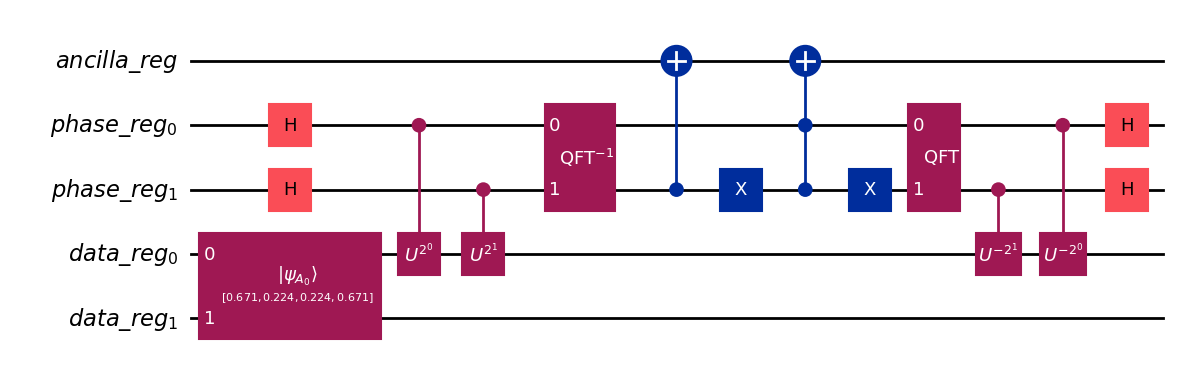

In [ ]:
'''
Drawing the quantum circuit for the quantum state |psi_A_0⟩, the matrix A_0 for the QPE, a threshold value tau,
an evolution time t for the QPE and a number n of qubits for the phase register
'''

t = 0.25
n = 2
qc_demo, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi_A_0, A_0, tau=0.8, t=t, n=n, psi_label=r'$|\psi_{A_0}\rangle$')
qc_demo.draw(output='mpl', fold=120)

# Post-selection and second phase estimation
## Post-selection on the ancilla qubit

In [141]:
'''
The function postselect_data_reg post-selects the statevector of a quantum circuit
on the ancilla qubit equaling ancilla_value, traces out phase_reg by incoherently summing
probabilities (not amplitudes) of matching data_reg basis states, and returns the
post-selection probability along with the renormalised amplitude magnitudes of data_reg.

postselect_data_reg: (QuantumCircuit, QuantumRegister, QuantumRegister, integer)
➜ (float, numpy.ndarray)
'''

def postselect_data_reg(qc, ancilla_reg, data_reg, ancilla_value=1):
    
    data_idx = [qc.find_bit(q).index for q in data_reg]
    ancilla_idx = qc.find_bit(ancilla_reg[0]).index

    state_vec = Statevector.from_instruction(qc)
    dim_data = 2 ** len(data_reg)
    probs = np.zeros(dim_data)
    ancilla_prob = 0
    
    for i, sv_amp in enumerate(state_vec.data):
        if (i >> ancilla_idx) & 1 == ancilla_value:
            idxval = sum(((i >> qi) & 1) << j for j, qi in enumerate(data_idx))
            p = abs(sv_amp) ** 2
            ancilla_prob += p
            probs[idxval] += p

    if ancilla_prob > 1e-9:
        probs = np.sqrt(probs/ancilla_prob)

    return ancilla_prob, probs

The function `postselect_data_reg`
```python
postselect_data_reg(qc, ancilla_reg, data_reg, ancilla_value=1)
```
takes the statevector of a circuit `qc` and extracts the magnitudes of the reduced state of `data_reg` conditioned on `ancilla_reg` being measured in the state `ancilla_value`. This implements the post-selection on $\lambda_k>\tau$ mentioned at the end of the qPCA circuit assembly.

**(i) Locating the relevant qubits.**
```python
data_idx = [qc.find_bit(q).index for q in data_reg]
ancilla_idx = qc.find_bit(ancilla_reg[0]).index
```
Since `qc` may contain other registers (e.g. `phase_reg`), `find_bit` is used to recover the absolute qubit index within `qc` of each qubit in `data_reg`, as well as the absolute index of the ancilla qubit. These indices are needed to read off the correct bits from the integer basis-state labels of the full statevector.

**(ii) Statevector of the quantum circuit.**
```python
state_vec = Statevector.from_instruction(qc)
dim_data = 2 ** len(data_reg)
probs = np.zeros(dim_data)
ancilla_prob = 0
```
`state_vec` holds the amplitude $c_i$ of each computational basis state $|i\rangle$ of the circuit, where $i$ ranges over $0,\dots,2^N-1$, $N$ is the number of qubits in `qc`, and $i$'s binary expansion is $i=\sum_qb_q(i)\;\!2^q$ with $b_q(i)\in\{0,1\}$ the value of qubit $q$ in basis state $|i\rangle$. The array `probs` and the scalar `ancilla_prob` accumulate the (unnormalised) probabilities of the post-selected `data_reg` outcomes and the total probability of measuring the ancilla in `ancilla_value`.

**(iii) Selecting basis states with the correct ancilla value and repacking the data-register bits.**
```python
for i, sv_amp in enumerate(state_vec.data):
    if (i >> ancilla_idx) & 1 == ancilla_value:
```
The loop projects the statevector onto the subspace where the ancilla qubit equals `ancilla_value`. For each basis state $|i\rangle$, it checks the bit of $i$ at position `ancilla_idx` (via `(i >> ancilla_idx) & 1`) and keeps only the amplitudes where that bit matches `ancilla_value`. This corresponds to the projector
$$
\Pi_{\text{anc}={\tt ancilla\_value}}=\sum_{i:\,b_{\text{ancilla\_idx}}(i)={\tt ancilla\_value}}|i\rangle\langle i|.
$$
```python
idxval = sum(((i >> qi) & 1) << j for j, qi in enumerate(data_idx))
```
Each surviving basis state $|i\rangle$ still encodes the values of all qubits in `qc`, including `phase_reg` and `ancilla_reg`. To obtain a state label for `data_reg` alone, the bit of $i$ at each position `qi` in `data_idx` is extracted via `(i >> qi) & 1`, then reassembled into a new integer `idxval` using its position $j$ within `data_reg`:
$$
{\tt idxval}=\sum_{j=0}^{|{\tt data\_reg}|-1}b_{{\tt data\_idx}[j]}(i)\;\!2^j.
$$

**(iv) Accumulating probability over `phase_reg`.**
```python
p = abs(sv_amp) ** 2
ancilla_prob += p
probs[idxval] += p
```
`ancilla_prob` accumulates $\sum|c_i|^2$ over all kept basis states, giving the probability $\Pr(\text{ancilla}={\tt ancilla\_value})$. `probs[idxval]` accumulates the probability $|c_i|^2$ (not the amplitude $c_i$ itself) into the slot for the corresponding `data_reg` basis state.

This matters when multiple surviving basis states share the same `idxval` but differ in their `phase_reg` value. Since `phase_reg` isn't guaranteed to collapse back to $|0\rangle^{\otimes n}$ after the threshold operation, these different `phase_reg` branches are physically distinguishable outcomes, not the same amplitude split across paths that should interfere. So instead of adding the amplitudes $c_i$ together (which could cause spurious cancellation or reinforcement from leftover phases in `phase_reg`), we add their probabilities $|c_i|^2$. This is equivalent to tracing out `phase_reg`, treating it as a classical mixture rather than a coherent superposition.

This is the same operation `run_shots` performs empirically by counting outcomes over many shots; here it is computed exactly from the statevector instead of estimated from measurement statistics.

**(v) Normalisation and outputs.**

```python
if ancilla_prob > 1e-9:
    probs = np.sqrt(probs/ancilla_prob)

return ancilla_prob, probs
```
Dividing by `ancilla_prob` (when it is larger than zero) turns the unnormalised, post-selected probabilities into a properly normalised probability distribution over `data_reg`'s basis states, $\sum_{\tt idxval}{\tt probs}[{\tt idxval}]=1$. Taking the square root gives the magnitude of each amplitude,
$$
\big|\langle {\tt idxval}\mid\psi_{\text{post}}\rangle\big| \;\approx\; \sqrt{{\tt probs}[{\tt idxval}]},
$$
for the post-selected mixed state on `data_reg`.

The function `postselect_data_reg` returns both `ancilla_prob` (the probability of the post-selected outcome) and probs (the array of amplitude magnitudes with no phase information, since phase is not well-defined once `phase_reg` carries residual, outcome-dependent entanglement with `data_reg`).

Non-zero amplitudes of |psi_A_0⟩: {0: 0.671, 1: 0.224, 2: 0.224, 3: 0.671}

τ=1.1: Probability(ancilla=1)=0.80
 Non-zero |amplitude| obtained by the quantum circuit: {0: 0.5, 1: 0.5, 2: 0.5, 3: 0.5}
 Expected non-zero amplitudes: {0: 0.5, 1: 0.5, 2: 0.5, 3: 0.5}

τ=0.8: Probability(ancilla=1)=1.00
 Non-zero |amplitude| obtained by the quantum circuit: {0: 0.671, 1: 0.224, 2: 0.224, 3: 0.671}
 Expected non-zero amplitudes: {0: 0.671, 1: 0.224, 2: 0.224, 3: 0.671}


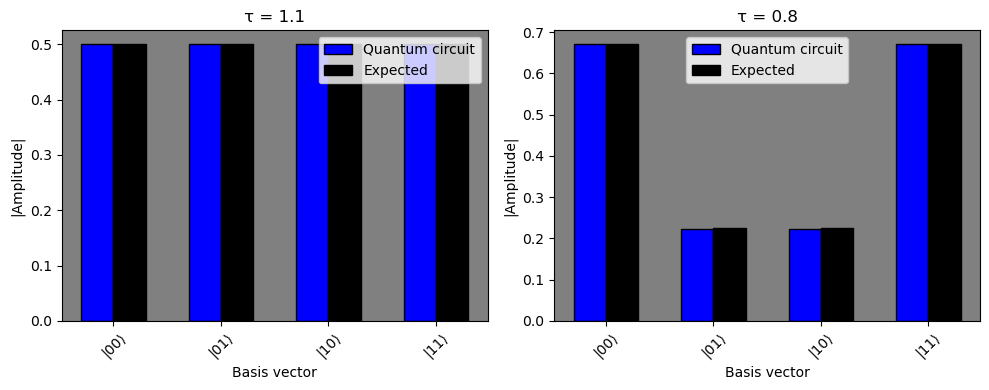

In [142]:
# Definition of the list of τ's and corresponding dictionaries of expected amplitudes

tau_list = [1.1, 0.8]
expected_dicts = [{0: 0.5, 1: 0.5, 2: 0.5, 3: 0.5}, {0: 0.671, 1: 0.224, 2: 0.224, 3: 0.671}]

# Print of the non-zero amplitudes of |psi_A_0⟩

print('Non-zero amplitudes of |psi_A_0⟩:', {idx: round(float(amp), 3) for idx, amp in enumerate(psi_A_0) if abs(amp) > 1e-9})

# Definition of number of qubits to encode A_0, number of states and figure parameters

n_qubits = encoding_qubits(A_0)
n_states = 2**n_qubits
x = np.arange(n_states)

labels = [f'|{i:0{n_qubits}b}⟩' for i in range(n_states)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
width = 0.3

# Computation and plot of expected (resp. obtained) non-zero amplitudes for each τ

for ax, tau, expected_dict in zip(axes, tau_list, expected_dicts):

    qc, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi_A_0, A_0, tau=tau, t=t, n=n)
    ancilla_prob, qc_mag = postselect_data_reg(qc, ancilla_reg, data_reg)
    nz_qc_mag = {idx: round(float(mag), 3) for idx, mag in enumerate(qc_mag) if mag > 1e-9}
    
    expected_amp = np.zeros(n_states)
    expected_amp[list(expected_dict.keys())] = list(expected_dict.values())

    print(f'\nτ={tau}: Probability(ancilla=1)={ancilla_prob:.2f}')
    print(f' Non-zero |amplitude| obtained by the quantum circuit: {nz_qc_mag}')
    print(f' Expected non-zero amplitudes: {expected_dict}')

    ax.bar(x - width/2, qc_mag, width, label='Quantum circuit', color='blue', edgecolor='black')
    ax.bar(x + width/2, expected_amp, width, label='Expected', color='black', edgecolor='black')
    ax.set(facecolor='gray', title=f'τ = {tau}', xlabel='Basis vector', ylabel='|Amplitude|')
    ax.set_xticks(x, labels, rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

## Second phase estimation: recovering eigenvalues

In [143]:
# Second phase estimation and recovery of the eigenvalues

for tau in tau_list:
    qc, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi_A_0, A_0, tau=tau, t=t, n=n, second_qpe=True)

    ancilla_idx = qc.find_bit(ancilla_reg[0]).index
    lambda_idx = [qc.find_bit(q).index for q in phase_reg]

    state_vec = Statevector.from_instruction(qc)
    ancilla_prob, lambda_probs = 0, {}
    
    for i, sv_amp in enumerate(state_vec.data):
        if (i >> ancilla_idx) & 1 == 1:
            ancilla_prob += abs(sv_amp) ** 2
            k = sum(((i >> qi) & 1) << j for j, qi in enumerate(lambda_idx))
            lambda_probs[k] = lambda_probs.get(k, 0) + abs(sv_amp) ** 2

    print(f'τ={tau}: P(ancilla=1)={ancilla_prob:.2f}')
    for k, p in sorted(lambda_probs.items()):
        lambda_k = k / (t * 2 ** len(phase_reg))
        print(f' P(λ ≈ {lambda_k:.1f} | ancilla=1) = {p/ancilla_prob:.2f}')
    print()

τ=1.1: P(ancilla=1)=0.80
 P(λ ≈ 0.0 | ancilla=1) = 0.00
 P(λ ≈ 1.0 | ancilla=1) = 0.00
 P(λ ≈ 2.0 | ancilla=1) = 1.00
 P(λ ≈ 3.0 | ancilla=1) = 0.00

τ=0.8: P(ancilla=1)=1.00
 P(λ ≈ 0.0 | ancilla=1) = 0.00
 P(λ ≈ 1.0 | ancilla=1) = 0.20
 P(λ ≈ 2.0 | ancilla=1) = 0.80
 P(λ ≈ 3.0 | ancilla=1) = 0.00



```python
for tau in tau_list:
    qc, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi_A_0, A_0, tau=tau, t=t, n=n, second_qpe=True)

    ancilla_idx = qc.find_bit(ancilla_reg[0]).index
    lambda_idx = [qc.find_bit(q).index for q in phase_reg]

    state_vec = Statevector.from_instruction(qc)
    ancilla_prob, lambda_probs = 0, {}
```
This step is a repetition of the $\tau$-sweep with `second_qpe=True`. The second forward QPE re-populates `phase_reg` with eigenvalue estimates and the code extracts the resulting probability distribution over `phase_reg`, conditioned on ancilla $=1$ (step 7 of the algorithm). The method `find_bit` returns the absolute index `ancilla_idx` of the ancilla qubit and the list of indices `lambda_idx` for each qubit of `phase_reg`, needed to read bits off the basis-state index $i$.
```python
for i, sv_amp in enumerate(state_vec.data):
    if (i >> ancilla_idx) & 1 == 1:
        ancilla_prob += abs(sv_amp) ** 2
        k = sum(((i >> qi) & 1) << j for j, qi in enumerate(lambda_idx))
        lambda_probs[k] = lambda_probs.get(k, 0) + abs(sv_amp) ** 2

print(f'τ = {tau}: P(ancilla=1) = {ancilla_prob:.2f}')
    for k, p in sorted(lambda_probs.items()):
        lambda_k = k / (t * 2 ** len(phase_reg))
        print(f' P(λ ≈ {lambda_k:.1f} | ancilla=1) = {p/ancilla_prob:.2f}')
    print()
```
As in `postselect_data_reg`, the statevector `state_vec` is parsed and only basis states $|i\rangle$ with ancilla bit $=1$ are kept, accumulating ${\tt anc\_prob}=\Pr(\text{ancilla}=1)$. The `phase_reg` bits of each surviving $i$ are repacked into a binary phase
$$
k=\sum_{j}b_{{\tt lambda\_idx}[j]}(i)\;\!2^j,
$$
which provides an eigenvalue estimate $\lambda_k\approx k/(t\cdot 2^{|{\tt phase\_reg}|})$. The probabilities are summed over basis states sharing the same $k$,
$$
{\tt lambda\_probs}[k]=\sum_{i:\ \text{anc}(i)=1,\ \text{phase}(i)=k}|{\tt sv\_amp}|^2,
\quad\text{(${\tt sv\_amp}=$ amplitude of basis state $|i\rangle$ in {\tt state\_vec}),}
$$
and normalised by dividing by `ancilla_prob`
$$
\Pr(\lambda\approx\lambda_k\mid\text{ancilla}=1)=\frac{{\tt lambda\_probs}[k]}{{\tt ancilla\_prob}}.
$$
The resulting probability should match $\lambda_k^2/\sum_{k\le t}\lambda_k^2$, confirming the second QPE recovers eigenvalues weighted by their squared contribution to $A_0$.

# Aer shot-based simulation

In [144]:
'''
The function run_shots estimates the ancilla post-selection probability and the amplitudes
of data-register outcomes using a shot-based Aer simulation. It runs the qPCA circuit for
the specified number of shots, post-selects measurement outcomes where the ancilla qubit
equals 1, and estimates each data-register amplitude as the square root of its empirical
conditional probability.

run_shots: (numpy.ndarray, numpy.ndarray, float, float, integer, integer) ➜ (float, dict)
'''

def run_shots(psi, A, tau, t, n, shots=10000):
    
    qc, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi, A, tau=tau, t=t, n=n)
    c_ancilla_reg = ClassicalRegister(1, 'c_ancilla_reg')
    c_data_reg = ClassicalRegister(len(data_reg), 'c_data_reg')
    qc.add_register(c_ancilla_reg)
    qc.add_register(c_data_reg)
    qc.measure(ancilla_reg[0], c_ancilla_reg[0])
    qc.measure(data_reg, c_data_reg)

    transpile_qc = transpile(qc, AerSimulator())
    counts = AerSimulator().run(transpile_qc, shots=shots).result().get_counts()

    data_counts = Counter()
    for key, count in counts.items():
        data_key, ancilla_key = key.split()
        if ancilla_key == '1':
            data_counts[data_key] += count

    surviving_shots = sum(data_counts.values())
    amplitude_est = {k: math.sqrt(v/surviving_shots) for k, v in data_counts.items()}
    
    return surviving_shots/shots, amplitude_est

The function `run_shots`
```python
run_shots(psi, A, tau, t, n, shots=10000)
```
measures the qPCA circuit built by `build_qpca_circuit` several times on [Aer simulator](https://qiskit.github.io/qiskit-aer), and turns the resulting statistics into an estimate of the post-thresholding quantum state.

**(i) Building and measuring the circuit.**

```python
qc, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi, A, tau=tau, t=t, n=n)
```
This produces the qPCA circuit. `ancilla_reg` holds the threshold flag $1[\lambda_k > \tau]$, and `data_reg` holds $|u_k\rangle$. Since `second_qpe` defaults to `False`, `phase_reg` is uncomputed back to $|0\rangle^{\otimes n}$ and carries no information at this stage.
```python
c_ancilla_reg = ClassicalRegister(1, 'c_ancilla_reg')
c_data_reg = ClassicalRegister(len(data_reg), 'c_data_reg')
qc.add_register(c_ancilla_reg)
qc.add_register(c_data_reg)
qc.measure(ancilla_reg[0], c_ancilla_reg[0])
qc.measure(data_reg, c_data_reg)
```
Two classical registers are attached and measured. `c_ancilla_reg` captures the threshold flag, `c_data_reg` captures the data-register outcome $|u_k\rangle$ collapses to. Because `ancilla_reg` and `data_reg` are entangled through the threshold operation, each shot yields a joint outcome $(a, x)$ with probability
$$
P(a, x)=\sum_{k:\,u_k\mapsto x}|\langle x|\psi\rangle|^2\cdot 1_{\{(a=1)\Leftrightarrow(\lambda_k>\tau)\}}.
$$

**(ii) Running the simulation and post-selecting on the ancilla.**
```python
transpile_qc = transpile(qc, AerSimulator())
counts = AerSimulator().run(transpile_qc, shots=shots).result().get_counts()
```
The circuit is [transpiled](https://quantum.cloud.ibm.com/docs/en/guides/transpile) for `AerSimulator` and executed `shots` times. `counts` is a dictionary mapping each observed bitstring to how many of the `shots` runs produced it. Each key is a space-separated string combining the two classical registers, printed in reverse-declaration order, i.e. `'⟨c_data_reg⟩ ⟨c_ancilla_reg⟩'`.
```python
data_counts = Counter()
for key, count in counts.items():
    data_key, ancilla_key = key.split()
    if ancilla_key == '1':
        data_counts[data_key] += count
```
This discards every shot where the ancilla flag is $0$ (i.e. $\lambda_k\le\tau$), keeping only shots where the eigenvalue exceeds the threshold. `data_counts[x]` accumulates, over those retained shots, how many times data-outcome $x$ occurs.

**(iii) Estimating probabilities and amplitudes.**

```python
surviving_shots = sum(data_counts.values())
amplitude_est = {k: math.sqrt(v/surviving_shots) for k, v in data_counts.items()}
return surviving_shots/shots, amplitude_est
```
`surviving_shots` is the number of shots surviving post-selection. So
$$
P(\text{ancilla}=1)\approx\frac{\texttt{surviving\_shots}}{\texttt{shots}}
$$
is the fraction of shots landing above threshold — an empirical estimate of the probability mass carried by principal eigenvectors of $A$. Conditioned on that event, the empirical conditional probability of each data outcome $x$ is
$$
P(x\mid\text{ancilla}=1)\approx\frac{\texttt{data\_counts}[x]}{\texttt{surviving\_shots}}.
$$
Since Born's rule implies that $P(x\mid\text{ancilla}=1)=|\langle x\mid\psi_{\text{post}}\rangle|^2$ for the post-selected state $|\psi_{\text{post}}\rangle$, taking the square root gives an estimate of the amplitude magnitude:
$$
\texttt{amplitude\_est}[x]
=\sqrt{\frac{\texttt{data\_counts}[x]}{\texttt{surviving\_shots}}}
\approx|\langle x|\psi_{\text{post}}\rangle|.
$$
(only the magnitude is recoverable since projective measurement destroys phase information)

The function returns the pair `(P(ancilla=1), amplitude_est)`: a scalar estimate of how much of $|\psi\rangle$'s weight sits on eigenvalues above $\tau$, and a dictionary of estimated amplitude magnitudes over `data_reg`'s computational basis, conditioned on that thresholding event.

In [145]:
# Aer shot-based simulation for A_0

for tau, expected in zip(tau_list, expected_dicts):
    prob, amplitude_est = run_shots(psi_A_0, A_0, tau=tau, t=t, n=n)
    print(f'τ={tau}: P(ancilla=1)≈{prob:.2f} (shot noise)')
    print(' estimated |amplitude| per data-register outcome:', {k: round(v, 3) for k, v in sorted(amplitude_est.items())}, '\n')

τ=1.1: P(ancilla=1)≈0.80 (shot noise)
 estimated |amplitude| per data-register outcome: {'00': 0.507, '01': 0.494, '10': 0.496, '11': 0.502} 

τ=0.8: P(ancilla=1)≈1.00 (shot noise)
 estimated |amplitude| per data-register outcome: {'00': 0.668, '01': 0.225, '10': 0.231, '11': 0.671} 



# Second example: 4x4 diagonal matrix

Let $C$ be the diagonal matrix of Section V.B of He et al.,
$$
C=
\begin{pmatrix}
0 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 2 & 0\\
0 & 0 & 0 & 3
\end{pmatrix},
$$
which has eigenvalues and eigenvectors
$$
\lambda_1=0,~\lambda_2=1,~\lambda_3=2,~\lambda_4=3
\quad\text{and}\quad
u_1=\begin{pmatrix}1\\0\\0\\0\end{pmatrix},~
u_2=\begin{pmatrix}0\\1\\0\\0\end{pmatrix},~
u_3=\begin{pmatrix}0\\0\\1\\0\end{pmatrix},~
u_4=\begin{pmatrix}0\\0\\0\\1\end{pmatrix}.
$$
Using a $4$-qubit register, the matric $C$ can be encoded into a quantum state with non-zero amplitudes at indices $5$ ($=0101$), $10$ ($=1010$) and $15$ ($=1111$), namely,
$$
|\psi_C\rangle
=\tfrac1{\sqrt{14}}(|0101\rangle+2\;\!|1010\rangle+3\;\!|1111\rangle)
\approx 0.267\;\!|0101\rangle+0.535\;\!|1010\rangle+0.802\;\!|1111\rangle.
$$
For the choice of threshold value $\tau=1.1$, the components corresponding to $\lambda_3=2$ and $\lambda_4=3$ should survive, that is,
$$
\tfrac1{\sqrt{14}}(2\;\!|1010\rangle+3\;\!|1111\rangle),
$$
which gives after normalisation the quantum state
$$
\sqrt{\tfrac{14}{13}}\cdot\tfrac1{\sqrt{14}}(2\;\!|1010\rangle+3\;\!|1111\rangle)
\approx0.555\;\!|1010\rangle+0.832\;\!|1111\rangle).
$$
On the other hand, for the choice of threshold value $\tau=0.5$, the components corresponding to $\lambda_2=1$, $\lambda_3=2$ and $\lambda_4=3$ should survive, and thus give the initial quantum state
$$
|\psi_C\rangle\approx 0.267\;\!|0101\rangle+0.535\;\!|1010\rangle+0.802\;\!|1111\rangle.
$$

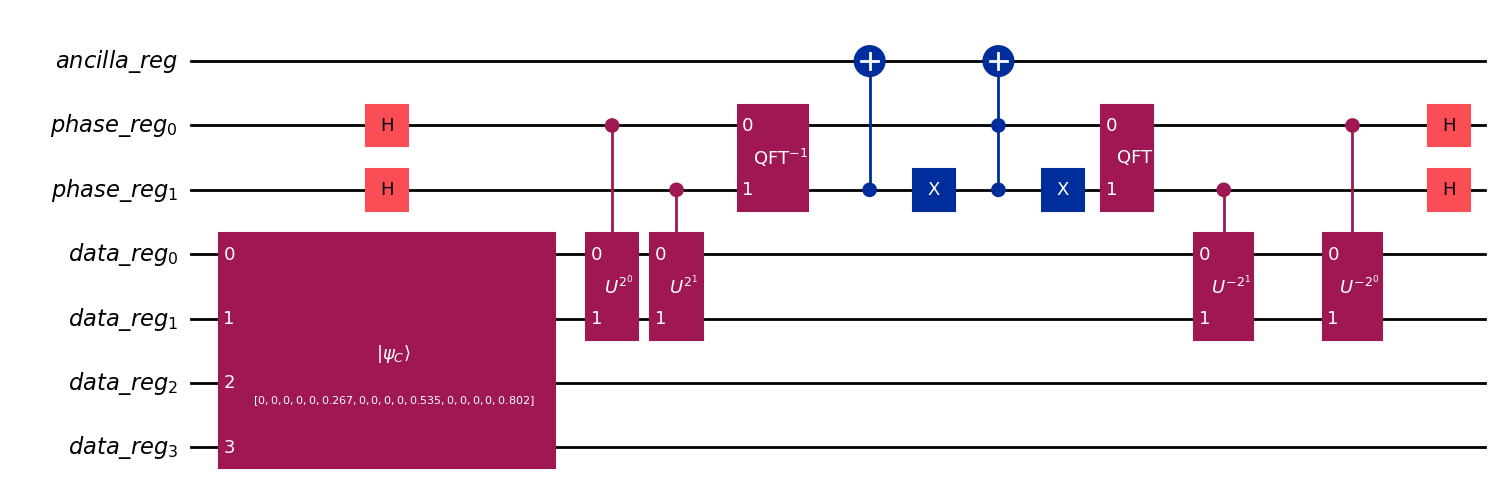

In [ ]:
# Definition of the matrix C and corresponding quantum state |psi_C⟩

C = np.diag([0, 1, 2, 3])
psi_C = C.flatten() / np.linalg.norm(C.flatten())

'''
Drawing of the quantum circuit for the quantum state |psi_C⟩, the matrix C for the QPE, a threshold value tau,
an evolution time t for the QPE and a number n of qubits for the phase register 
'''

t = 0.25
n = 2
qc_demo, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi_C, C, tau=0.5, t=t, n=n, psi_label=r'$|\psi_C\rangle$')
qc_demo.draw(output='mpl', fold=120)

Non-zero amplitudes of |psi_C⟩: {5: 0.267, 10: 0.535, 15: 0.802}

τ=1.1: Probability(ancilla=1)=0.93
 Non-zero |amplitude| obtained by the quantum circuit: {10: 0.555, 15: 0.832}
 Expected non-zero amplitudes: {10: 0.555, 15: 0.832}

τ=0.5: Probability(ancilla=1)=1.00
 Non-zero |amplitude| obtained by the quantum circuit: {5: 0.267, 10: 0.535, 15: 0.802}
 Expected non-zero amplitudes: {5: 0.267, 10: 0.535, 15: 0.802}


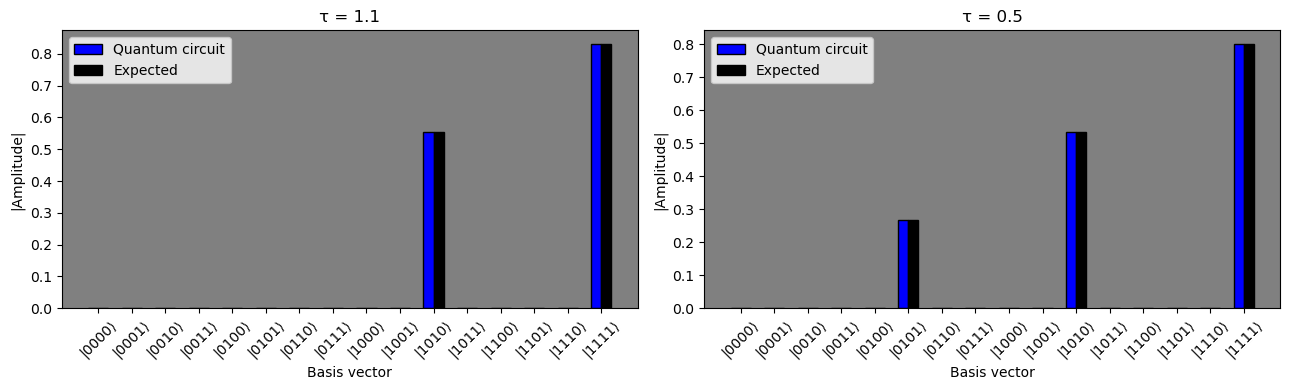

In [147]:
# Definition of the list of τ's and corresponding dictionaries of expected amplitudes

tau_list = [1.1, 0.5]
expected_dicts = [{10: 0.555, 15: 0.832}, {5: 0.267, 10: 0.535, 15: 0.802}]

# Print of the non-zero amplitudes of |psi_C⟩

print('Non-zero amplitudes of |psi_C⟩:', {idx: round(float(amp), 3) for idx, amp in enumerate(psi_C) if abs(amp) > 1e-9})

# Definition of number of qubits to encode C, number of states and figure parameters

n_qubits = encoding_qubits(C)
n_states = 2**n_qubits
x = np.arange(n_states)

labels = [f'|{i:0{n_qubits}b}⟩' for i in range(n_states)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
width = 0.3

# Computation and plot of expected (resp. obtained) non-zero amplitudes for each τ

for ax, tau, expected_dict in zip(axes, tau_list, expected_dicts):

    qc, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi_C, C, tau=tau, t=t, n=n)
    ancilla_prob, qc_mag = postselect_data_reg(qc, ancilla_reg, data_reg)
    nz_qc_mag = {idx: round(float(mag), 3) for idx, mag in enumerate(qc_mag) if mag > 1e-9}
    
    expected_amp = np.zeros(n_states)
    expected_amp[list(expected_dict.keys())] = list(expected_dict.values())

    print(f'\nτ={tau}: Probability(ancilla=1)={ancilla_prob:.2f}')
    print(f' Non-zero |amplitude| obtained by the quantum circuit: {nz_qc_mag}')
    print(f' Expected non-zero amplitudes: {expected_dict}')

    ax.bar(x - width/2, qc_mag, width, label='Quantum circuit', color='blue', edgecolor='black')
    ax.bar(x + width/2, expected_amp, width, label='Expected', color='black', edgecolor='black')
    ax.set(facecolor='gray', title=f'τ = {tau}', xlabel='Basis vector', ylabel='|Amplitude|')
    ax.set_xticks(x, labels, rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

In [148]:
# Second phase estimation and recovery of the eigenvalues for C

for tau in tau_list:
    qc, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi_C, C, tau=tau, t=t, n=n, second_qpe=True)

    ancilla_idx = qc.find_bit(ancilla_reg[0]).index
    lambda_idx = [qc.find_bit(q).index for q in phase_reg]

    state_vec = Statevector.from_instruction(qc)
    ancilla_prob, lambda_probs = 0, {}
    
    for i, sv_amp in enumerate(state_vec.data):
        if (i >> ancilla_idx) & 1 == 1:
            ancilla_prob += abs(sv_amp) ** 2
            k = sum(((i >> qi) & 1) << j for j, qi in enumerate(lambda_idx))
            lambda_probs[k] = lambda_probs.get(k, 0) + abs(sv_amp) ** 2

    print(f'τ={tau}: P(ancilla=1)={ancilla_prob:.2f}')
    for k, p in sorted(lambda_probs.items()):
        lambda_k = k / (t * 2 ** len(phase_reg))
        print(f' P(λ ≈ {lambda_k:.1f} | ancilla=1) = {p/ancilla_prob:.2f}')
    print()

τ=1.1: P(ancilla=1)=0.93
 P(λ ≈ 0.0 | ancilla=1) = 0.00
 P(λ ≈ 1.0 | ancilla=1) = 0.00
 P(λ ≈ 2.0 | ancilla=1) = 0.31
 P(λ ≈ 3.0 | ancilla=1) = 0.69

τ=0.5: P(ancilla=1)=1.00
 P(λ ≈ 0.0 | ancilla=1) = 0.00
 P(λ ≈ 1.0 | ancilla=1) = 0.07
 P(λ ≈ 2.0 | ancilla=1) = 0.29
 P(λ ≈ 3.0 | ancilla=1) = 0.64



In [149]:
# Aer shot-based simulation for C

for tau, expected in zip(tau_list, expected_dicts):
    prob, amplitude_est = run_shots(psi_C, C, tau=tau, t=t, n=n)
    print(f'τ={tau}: P(ancilla=1)≈{prob:.2f} (shot noise)')
    print(' estimated |amplitude| per data-register outcome:', {k: round(v, 3) for k, v in sorted(amplitude_est.items())}, '\n')

τ=1.1: P(ancilla=1)≈0.93 (shot noise)
 estimated |amplitude| per data-register outcome: {'1010': 0.556, '1111': 0.831} 

τ=0.5: P(ancilla=1)≈1.00 (shot noise)
 estimated |amplitude| per data-register outcome: {'0101': 0.267, '1010': 0.528, '1111': 0.806} 



# Third example: 2x2 matrix with non-integer eigenvalues

Let $D$ be the $2\times2$ matrix of Section V.A of [[1]](#ref1),
$$
D=
\begin{pmatrix}
0.6507 & 0.2122\\
0.2122 & 0.6507\\
\end{pmatrix},
$$
which has eigenvalues and eigenvectors
$$
\lambda_1=0.863,~\lambda_2=0.438
\quad\text{and}\quad
u_1=\tfrac1{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix},~
u_2=\tfrac1{\sqrt{2}}\begin{pmatrix}-1\\1\end{pmatrix}.
$$
Using a $2$-qubit register, the matrix $D$ can be encoded into a quantum state with non-zero amplitudes at indices $0$ ($=00$), $1$ ($=01$), $2$ ($=10$) and $3$ ($=11$), namely,
$$
|\psi_D\rangle
\approx\tfrac1{0.968}(0.6507\;\!|00\rangle+0.2122\;\!|01\rangle+0.2122\;\!|10\rangle+0.6507\;\!|11\rangle)
\approx0.672\;\!|00\rangle+0.219\;\!|01\rangle+0.219\;\!|10\rangle+0.672\;\!|11\rangle.
$$
For the choice of threshold value $\tau=0.5$, only the component of $D$ corresponding to $\lambda_1=0.863$ should survive. It is equal to the following by the spectral theorem
$$
\lambda_1u_1^Tu_1
=0.863\cdot\tfrac1{\sqrt2}(1,1)\cdot
\tfrac1{\sqrt2}\begin{pmatrix}
1\\
1
\end{pmatrix}
\approx0.432\begin{pmatrix}
1 & 1\\
1 & 1
\end{pmatrix}.
$$
After amplitude encoding and normalisation, this yields the quantum state
$$
\tfrac12(|00\rangle+|01\rangle+|10\rangle+|11\rangle).
$$
On the other hand, for the choice of threshold value $\tau=0.1$, both the components corresponding to $\lambda_1=0.863$ and $\lambda_2=0.438$ should survive, thus giving again the initial quantum state
$$
|\psi_D\rangle\approx0.672\;\!|00\rangle+0.219\;\!|01\rangle+0.219\;\!|10\rangle+0.672\;\!|11\rangle.
$$

In [150]:
# Computation of the eigenvalues, eigenvectors and quantum state of D with classical libraries
# The eigenvectors of D are ordered by their eigenvalues

D = np.array([[0.6507, 0.2122], [0.2122, 0.6507]])
evals, evecs = np.linalg.eigh(D)
evals, evecs = evals[::-1], evecs[:,::-1]
psi_D = D.flatten() / np.linalg.norm(D.flatten())

print('Eigenvalues of the matrix D:', evals)
print('\nEigenvectors of the matrix D (column vectors):\n', evecs)
print('\nNon-zero amplitudes of |psi_D⟩:', {idx: round(float(amp), 3) for idx, amp in enumerate(psi_D) if abs(amp) > 1e-9})

Eigenvalues of the matrix D: [0.863 0.438]

Eigenvectors of the matrix D (column vectors):
 [[ 0.707 -0.707]
 [ 0.707  0.707]]

Non-zero amplitudes of |psi_D⟩: {0: 0.672, 1: 0.219, 2: 0.219, 3: 0.672}


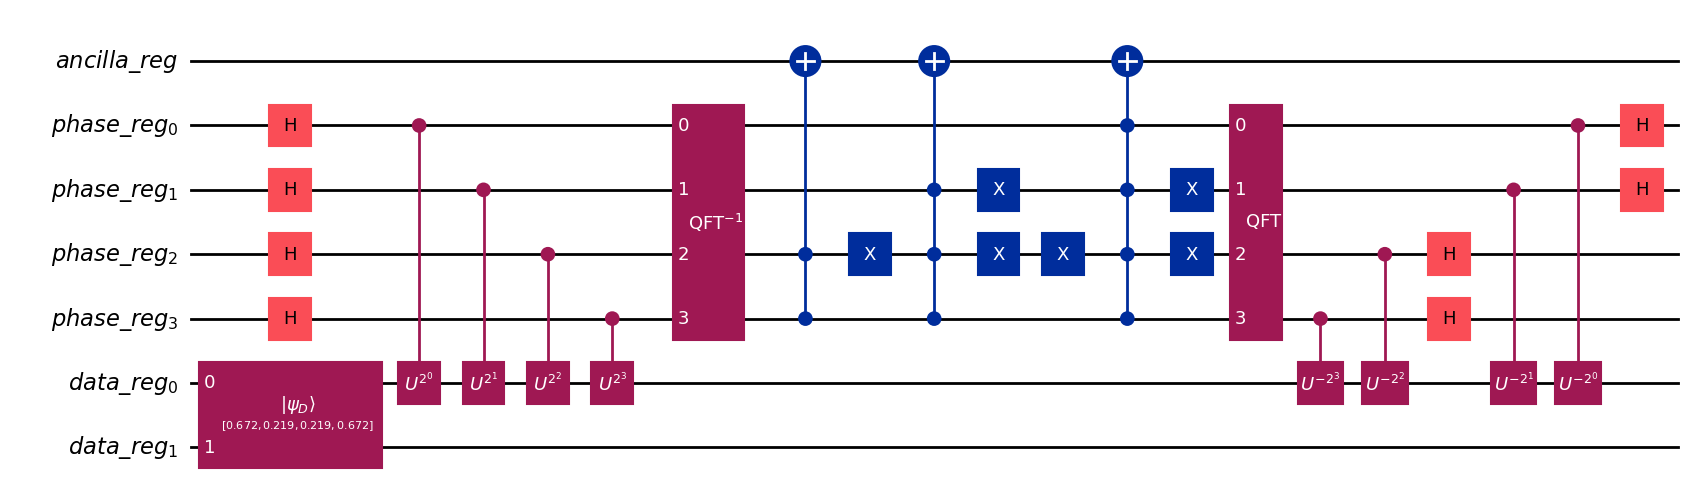

In [ ]:
'''
Drawing of the quantum circuit for the quantum state |psi_D⟩, the matrix choice D for the QPE, a threshold value tau,
an evolution time t for the QPE and a number n of qubits for the phase register
'''

t = 1
n = 4
qc_demo, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi_D, D, tau=0.5, t=t, n=n, psi_label=r'$|\psi_D\rangle$')
qc_demo.draw(output='mpl', fold=120)

Non-zero amplitudes of |psi_D⟩: {0: 0.672, 1: 0.219, 2: 0.219, 3: 0.672}

τ=0.5: Probability(ancilla=1)=0.78
 Non-zero |amplitude| obtained by the quantum circuit: {0: 0.5, 1: 0.5, 2: 0.5, 3: 0.5}
 Expected non-zero amplitudes: {0: 0.5, 1: 0.5, 2: 0.5, 3: 0.5}

τ=0.1: Probability(ancilla=1)=0.99
 Non-zero |amplitude| obtained by the quantum circuit: {0: 0.672, 1: 0.22, 2: 0.22, 3: 0.672}
 Expected non-zero amplitudes: {0: 0.672, 1: 0.219, 2: 0.219, 3: 0.672}


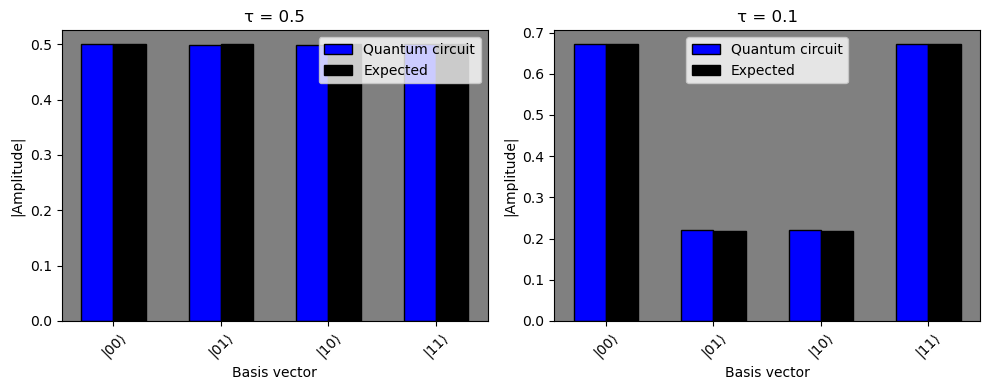

In [152]:
# Definition of the list of τ's and corresponding dictionaries of expected amplitudes

tau_list = [0.5, 0.1]
expected_dicts = [{0: 0.5, 1: 0.5, 2: 0.5, 3: 0.5}, {0: 0.672, 1: 0.219, 2: 0.219, 3: 0.672}]

# Print of the non-zero amplitudes of |psi_D⟩

print('Non-zero amplitudes of |psi_D⟩:', {idx: round(float(amp), 3) for idx, amp in enumerate(psi_D) if abs(amp) > 1e-9})

# Definition of number of qubits to encode D, number of states and figure parameters

n_qubits = encoding_qubits(D)
n_states = 2**n_qubits
x = np.arange(n_states)

labels = [f'|{i:0{n_qubits}b}⟩' for i in range(n_states)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
width = 0.3

# Computation and plot of expected (resp. obtained) non-zero amplitude magnitudes for each τ

for ax, tau, expected_dict in zip(axes, tau_list, expected_dicts):
    qc, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi_D, D, tau=tau, t=t, n=n)
    ancilla_prob, qc_mag = postselect_data_reg(qc, ancilla_reg, data_reg)
    nz_qc_mag = {idx: round(float(mag), 3) for idx, mag in enumerate(qc_mag) if mag > 1e-9}
    
    expected_amp = np.zeros(n_states)
    expected_amp[list(expected_dict.keys())] = list(expected_dict.values())

    print(f'\nτ={tau}: Probability(ancilla=1)={ancilla_prob:.2f}')
    print(f' Non-zero |amplitude| obtained by the quantum circuit: {nz_qc_mag}')
    print(f' Expected non-zero amplitudes: {expected_dict}')

    ax.bar(x - width/2, qc_mag, width, label='Quantum circuit', color='blue', edgecolor='black')
    ax.bar(x + width/2, expected_amp, width, label='Expected', color='black', edgecolor='black')
    ax.set(facecolor='gray', title=f'τ = {tau}', xlabel='Basis vector', ylabel='|Amplitude|')
    ax.set_xticks(x, labels, rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

In [153]:
# Second phase estimation and recovery of the eigenvalues for D

for tau in tau_list:
    qc, ancilla_reg, phase_reg, data_reg = build_qpca_circuit(psi_D, D, tau=tau, t=t, n=n, second_qpe=True)

    ancilla_idx = qc.find_bit(ancilla_reg[0]).index
    lambda_idx = [qc.find_bit(q).index for q in phase_reg]

    state_vec = Statevector.from_instruction(qc)
    ancilla_prob, lambda_probs = 0, {}
    
    for i, sv_amp in enumerate(state_vec.data):
        if (i >> ancilla_idx) & 1 == 1:
            ancilla_prob += abs(sv_amp) ** 2
            k = sum(((i >> qi) & 1) << j for j, qi in enumerate(lambda_idx))
            lambda_probs[k] = lambda_probs.get(k, 0) + abs(sv_amp) ** 2

    print(f'τ={tau}: P(ancilla=1)={ancilla_prob:.2f}')
    for k, p in sorted(lambda_probs.items()):
        lambda_k = k / (t * 2 ** len(phase_reg))
        print(f' P(λ ≈ {lambda_k:.3f} | ancilla=1) = {p/ancilla_prob:.2f}')
    print()

τ=0.5: P(ancilla=1)=0.78
 P(λ ≈ 0.000 | ancilla=1) = 0.00
 P(λ ≈ 0.062 | ancilla=1) = 0.00
 P(λ ≈ 0.125 | ancilla=1) = 0.00
 P(λ ≈ 0.188 | ancilla=1) = 0.00
 P(λ ≈ 0.250 | ancilla=1) = 0.00
 P(λ ≈ 0.312 | ancilla=1) = 0.00
 P(λ ≈ 0.375 | ancilla=1) = 0.00
 P(λ ≈ 0.438 | ancilla=1) = 0.00
 P(λ ≈ 0.500 | ancilla=1) = 0.00
 P(λ ≈ 0.562 | ancilla=1) = 0.00
 P(λ ≈ 0.625 | ancilla=1) = 0.00
 P(λ ≈ 0.688 | ancilla=1) = 0.00
 P(λ ≈ 0.750 | ancilla=1) = 0.01
 P(λ ≈ 0.812 | ancilla=1) = 0.05
 P(λ ≈ 0.875 | ancilla=1) = 0.90
 P(λ ≈ 0.938 | ancilla=1) = 0.02

τ=0.1: P(ancilla=1)=0.99
 P(λ ≈ 0.000 | ancilla=1) = 0.00
 P(λ ≈ 0.062 | ancilla=1) = 0.00
 P(λ ≈ 0.125 | ancilla=1) = 0.00
 P(λ ≈ 0.188 | ancilla=1) = 0.00
 P(λ ≈ 0.250 | ancilla=1) = 0.00
 P(λ ≈ 0.312 | ancilla=1) = 0.00
 P(λ ≈ 0.375 | ancilla=1) = 0.00
 P(λ ≈ 0.438 | ancilla=1) = 0.21
 P(λ ≈ 0.500 | ancilla=1) = 0.00
 P(λ ≈ 0.562 | ancilla=1) = 0.00
 P(λ ≈ 0.625 | ancilla=1) = 0.00
 P(λ ≈ 0.688 | ancilla=1) = 0.00
 P(λ ≈ 0.750 | ancilla=1)

In [154]:
# Aer shot-based simulation for D

for tau, expected in zip(tau_list, expected_dicts):
    prob, amplitude_est = run_shots(psi_D, D, tau=tau, t=t, n=n)
    print(f'τ={tau}: P(ancilla=1)≈{prob:.2f} (shot noise)')
    print(' estimated |amplitude| per data-register outcome:', {k: round(v, 3) for k, v in sorted(amplitude_est.items())}, '\n')

τ=0.5: P(ancilla=1)≈0.77 (shot noise)
 estimated |amplitude| per data-register outcome: {'00': 0.509, '01': 0.505, '10': 0.492, '11': 0.493} 

τ=0.1: P(ancilla=1)≈0.99 (shot noise)
 estimated |amplitude| per data-register outcome: {'00': 0.673, '01': 0.223, '10': 0.216, '11': 0.671} 



# References

<a id="ref1"></a> [[1] E. Dri, A. Aita, T. Fioravanti, G. Franco, E. Giusto, G. Ranieri, D. Corbelletto, and B. Montrucchio, Towards an End-to-End Approach for Quantum Principal Component Analysis, IEEE International Conference on Quantum Computing and Engineering (QCE), 1–6, 2023](https://ieeexplore.ieee.org/document/10313821)

<a id="ref2"></a> [[2] G. H. Golub and C. F. Van Loan, Matrix Computations, 4th ed., Johns Hopkins University Press, 2013](https://www.press.jhu.edu/books/title/10678/matrix-computations)

<a id="ref3"></a> [[3] C. He, J. Li, W. Liu, and Z. J. Wang, A Low-Complexity Quantum Principal Component Analysis Algorithm, IEEE Transactions on Quantum Engineering, vol. 3, 1–13, 2022](https://ieeexplore.ieee.org/document/9669030)

<a id="ref4"></a> [[4] J. Lin, W.-S. Bao, S. Zhang, T. Li, and X. Wang, An improved quantum principal component analysis algorithm based on the quantum singular threshold method, Physics Letters A, 2019](https://www.sciencedirect.com/science/article/abs/pii/S0375960119305626)

<a id="ref5"></a> [[5] S. Lloyd, M. Mohseni, and P. Rebentrost, Quantum principal component analysis, Nature Physics 10, 631–633, 2014](https://doi.org/10.1038/nphys3029)

<a id="ref6"></a> [[6] M. A. Nielsen and I. L. Chuang, Quantum Computation and Quantum Information, Cambridge University Press, 2010](https://www.cambridge.org/highereducation/books/quantum-computation-and-quantum-information/01E10196D0A682A6AEFFEA52D53BE9AE)